# Nepali PDF Corpus — initial exploration

Dataset: [`himalaya-ai/nepali_pdf_corpus`](https://huggingface.co/datasets/himalaya-ai/nepali_pdf_corpus)

This notebook performs a small, streaming-first inspection before the corpus is added to the pretraining pipeline. At the time of inspection (2026-08-22), the Hub viewer reported one `train` split with 8,635 rows and the columns `id`, `text`, `url`, and `language`. The repository did not provide a dataset card or license declaration, so provenance and permitted use must be verified before training or redistribution.

In [2]:
from collections import Counter
from itertools import islice
import math
import re
import unicodedata

import matplotlib.pyplot as plt
from datasets import load_dataset

DATASET_ID = "himalaya-ai/nepali_pdf_corpus"
SPLIT = "train"
SAMPLE_SIZE = 100
PREVIEW_CHARS = 500

## Load a bounded sample

Streaming avoids downloading the complete corpus during exploration. Only the first `SAMPLE_SIZE` records are materialized. This is a convenience sample, not an unbiased estimate of the full dataset.

In [3]:
stream = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
rows = list(islice(stream, SAMPLE_SIZE))

assert rows, "The dataset returned no rows."
required_columns = {"id", "text", "url", "language"}
missing_columns = required_columns - set(rows[0])
assert not missing_columns, f"Missing expected columns: {sorted(missing_columns)}"

print(f"Loaded {len(rows):,} sampled rows")
print("Columns:", sorted(rows[0]))
print("Streaming features:", stream.features)

Loaded 100 sampled rows
Columns: ['id', 'language', 'text', 'url']
Streaming features: {'id': Value('string'), 'text': Value('string'), 'url': Value('string'), 'language': Value('string')}


In [4]:
def compact_preview(text: str, limit: int = PREVIEW_CHARS) -> str:
    text = re.sub(r"\s+", " ", text or "").strip()
    return text if len(text) <= limit else text[:limit] + " …"

for index, row in enumerate(rows[:3], start=1):
    print(f"\n--- Sample {index} ---")
    print("id      :", row["id"])
    print("language:", row["language"])
    print("url     :", row["url"])
    print("text    :", compact_preview(row["text"]))


--- Sample 1 ---
id      : 000630c0589c670df3dbd5ec7f57fd38
language: ne
url     : https://adanchulimun.gov.np/content/%E0%A4%B8%E0%A5%87%E0%A4%B5%E0%A4%BE-%E0%A4%95%E0%A4%B0%E0%A4%BE%E0%A4%B0%E0%A4%AE%E0%A4%BE-%E0%A4%95%E0%A4%BE%E0%A4%B0%E0%A5%8D%E0%A4%AF%E0%A4%B0%E0%A4%A4-%E0%A4%95%E0%A4%B0%E0%A5%8D%E0%A4%AE%E0%A4%9A%E0%A4%BE%E0%A4%B0%E0%A5%80%E0%A4%95%E0%A4%BE%E0%A5%87-%E0%A4%AE%E0%A5%8D%E0%A4%AF%E0%A4%BE%E0%A4%A6-%E0%A4%A5%E0%A4%AA-%E0%A4%A8%E0%A4%B9%E0%A5%81%E0%A4%A8%E0%A5%87-%E0%A4%B8%E0%A4%AE%E0%A5%8D%E0%A4%AC%E0%A4%A8%E0%A5%8D%E0%A4%A7%E0%A5%80-%E0%A4%B8%E0%A5%82%E0%A4%9A%E0%A4%A8%E0%A4%BE-%E0%A5%A4
text    : नतिजा प्रकाशन सम्बन्धि सुचना अ.हे.व./अ.न.मि सेवा करारमा लिने सम्बन्धि सूचना लक परियोजना न्युनतम ीमा संलग्न हुनका लागि निवेदन दिने सम्बन्धमा परिक्षा मिति तोकिएको सम्बन्धमा / IT परिक्षा मिति तोकीको सम्बन्धमा व्यवसायिक फलफुल खेति सम्बन्धि सूचना Invitation for bids Addendum notice of supply & delivery of health medicinal goods सेवा करारमा लिने सम्बन्धि सूचना थप हरू You are he

## Sample-level corpus diagnostics

The Devanagari ratio is measured over alphabetic Unicode characters. This helps reveal English-heavy or malformed records, but it is not a full language detector: Nepali documents can legitimately contain English names, URLs, and technical terms.

In [5]:
def is_devanagari(character: str) -> bool:
    codepoint = ord(character)
    return (
        0x0900 <= codepoint <= 0x097F
        or 0xA8E0 <= codepoint <= 0xA8FF
        or 0x11B00 <= codepoint <= 0x11B5F
    )

def devanagari_letter_ratio(text: str) -> float:
    letters = [char for char in (text or "") if unicodedata.category(char).startswith("L")]
    if not letters:
        return 0.0
    return sum(is_devanagari(char) for char in letters) / len(letters)

def percentile(values: list[int], fraction: float) -> int:
    ordered = sorted(values)
    index = min(len(ordered) - 1, math.ceil(fraction * len(ordered)) - 1)
    return ordered[index]

lengths = [len(row["text"] or "") for row in rows]
ratios = [devanagari_letter_ratio(row["text"]) for row in rows]
language_counts = Counter(row["language"] for row in rows)
duplicate_ids = len(rows) - len({row["id"] for row in rows})
duplicate_texts = len(rows) - len({row["text"] for row in rows})

print("Language labels        :", dict(language_counts))
print(f"Character length       : min={min(lengths):,}, median={percentile(lengths, 0.5):,}, p95={percentile(lengths, 0.95):,}, max={max(lengths):,}")
print(f"Mean Devanagari ratio  : {sum(ratios) / len(ratios):.3f}")
print(f"Rows below 80% ratio   : {sum(ratio < 0.8 for ratio in ratios):,}")
print(f"Duplicate IDs/texts    : {duplicate_ids:,}/{duplicate_texts:,}")
print(f"Empty texts/URLs       : {sum(not (row['text'] or '').strip() for row in rows):,}/{sum(not (row['url'] or '').strip() for row in rows):,}")

Language labels        : {'ne': 88, 'en': 12}
Character length       : min=206, median=1,903, p95=45,155, max=177,669
Mean Devanagari ratio  : 0.747
Rows below 80% ratio   : 38
Duplicate IDs/texts    : 0/3
Empty texts/URLs       : 0/0


In [7]:
# Compare document-level script detection with destructive Nepali-only cleaning.
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")
EMAIL_PATTERN = re.compile(r"\S+@\S+\.\S+")
ALLOWED_PUNCTUATION = "।॥,.!?:;()[]{}'%/&@₹–—-" + chr(34)
ORPHAN_PUNCTUATION = ALLOWED_PUNCTUATION.replace("।", "").replace("॥", "")
KEEP_PATTERN = re.compile(
    rf"[^\u0900-\u097F\s{re.escape(ALLOWED_PUNCTUATION)}]"
)
ORPHAN_PUNCT_TOKEN = re.compile(
    rf"(?<!\S)[{re.escape(ORPHAN_PUNCTUATION)}]+(?!\S)"
)

def clean_nepali_only(text: str) -> str:
    if not isinstance(text, str):
        return text
    cleaned = URL_PATTERN.sub(" ", text)
    cleaned = EMAIL_PATTERN.sub(" ", cleaned)
    cleaned = KEEP_PATTERN.sub("", cleaned)
    cleaned = ORPHAN_PUNCT_TOKEN.sub("", cleaned)
    cleaned = re.sub(r"[ \t]+", " ", cleaned)
    cleaned = re.sub(r"([,.;:/-])(\s*\1)+", r"\1", cleaned)
    cleaned = re.sub(r"\n\s*\n+", "\n", cleaned).strip()
    return cleaned if re.search(r"[\u0900-\u097F]", cleaned) else ""

RATIO_THRESHOLD = 0.80
comparison = []
for row in rows:
    original = row["text"] or ""
    cleaned = clean_nepali_only(original)
    comparison.append({
        "id": row["id"],
        "original": original,
        "cleaned": cleaned,
        "ratio_keep": devanagari_letter_ratio(original) >= RATIO_THRESHOLD,
        "cleaner_keep": bool(cleaned),
        "retained_fraction": len(cleaned) / len(original) if original else 0.0,
    })

agreement = Counter(
    (item["ratio_keep"], item["cleaner_keep"]) for item in comparison
)
print(f"Ratio detector kept (>= {RATIO_THRESHOLD:.0%}) : {sum(x['ratio_keep'] for x in comparison):,}/{len(comparison):,}")
print(f"Cleaner returned non-empty text : {sum(x['cleaner_keep'] for x in comparison):,}/{len(comparison):,}")
print("Agreement (ratio_keep, cleaner_keep):", dict(agreement))
print(f"Characters retained overall     : {sum(len(x['cleaned']) for x in comparison) / max(1, sum(len(x['original']) for x in comparison)):.1%}")

most_changed = sorted(
    (item for item in comparison if item["cleaner_keep"]),
    key=lambda item: item["retained_fraction"],
)[:2]
for item in most_changed:
    print(f"\n--- {item['id']} | retained {item['retained_fraction']:.1%} ---")
    print("Before:", compact_preview(item["original"], 300))
    print("After :", compact_preview(item["cleaned"], 300))

print("\nConclusion:")
print("- The ratio method is more robust for detecting predominantly Devanagari documents without destroying mixed-script text.")
print("- The regex method is stronger for producing Devanagari-only text, but one surviving Devanagari character is enough to keep a row and useful Latin terms are removed.")
print("- Recommended policy: use the ratio for document filtering, then apply cleaning only when a deliberately Devanagari-only experiment requires it.")

Ratio detector kept (>= 80%) : 62/100
Cleaner returned non-empty text : 95/100
Agreement (ratio_keep, cleaner_keep): {(False, True): 33, (True, True): 62, (False, False): 5}
Characters retained overall     : 84.8%

--- 0411617973e4ee9c43932cda3000a17a | retained 1.4% ---
Before: Government of Nepal Ministry of Energy, Water Resources and Irrigation Alternative Energy Promotion Centre Making Renewable Energy and Energy Efficiency Mainstream Supply in Nepal Old Website ने EN Alternative Energy Promotion Centre About Us AEPC Board Mission, Vision & Strategy Organization Struct …
After : ने विज्ञापन संशोधन सम्बन्धी सूचना

--- 00f9374c3d5657f4b7c48e4653f0c700 | retained 13.0% ---
Before: नेपाल धितोपत्र बोर्ड Securities Board of Nepal E-attendance Career सूची दर्ता Associate Member of A(+) A A(-) np Home About SEBON Board of Directors Management Team Human Resources Organization Structure Former Chairman Public Holidays Enforcement Actions Stock Exchange Supervision Credit Rating Age …
After

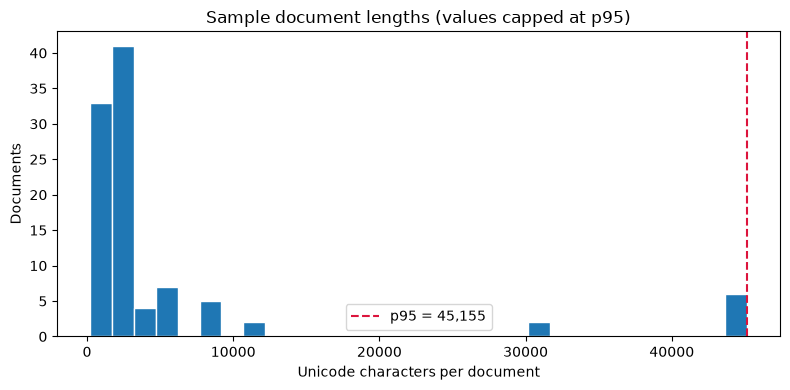

In [6]:
p95_length = percentile(lengths, 0.95)
plot_lengths = [min(length, p95_length) for length in lengths]

plt.figure(figsize=(8, 4))
plt.hist(plot_lengths, bins=30, edgecolor="white")
plt.axvline(p95_length, color="crimson", linestyle="--", label=f"p95 = {p95_length:,}")
plt.title("Sample document lengths (values capped at p95)")
plt.xlabel("Unicode characters per document")
plt.ylabel("Documents")
plt.legend()
plt.tight_layout()
plt.show()

## Preliminary suitability assessment

This corpus appears useful for formal Nepali and government/document-domain coverage, but it should not enter pretraining unchanged. Before pipeline integration we should:

1. Verify the corpus license, source permissions, and redistribution terms.
2. Inspect the full dataset rather than relying on this ordered convenience sample.
3. Deduplicate by normalized text in addition to `id`.
4. Remove navigation boilerplate, repeated headers/footers, OCR artifacts, and empty fragments;
5. retain mixed-script Nepali deliberately while filtering documents that are mostly unrelated languages;
6. split very long documents into boundary-aware chunks before tokenization; and
7. create deterministic document-level train/validation/test splits to prevent chunk leakage.

When the next two datasets are selected, use the same diagnostic cells so their domain, script mix, document lengths, duplication, licensing, and cleaning needs can be compared consistently.

# Full local Parquet EDA

The following cells analyze every downloaded row rather than the first 100 streamed records. They discover all Parquet shards under data/raw/nepali_pdf_corpus/data, so the same code continues to work if the repository is sharded later.

In [8]:
from pathlib import Path
from urllib.parse import urlparse
import json
import sys

import pandas as pd
import pyarrow.dataset as pads

candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (root for root in candidate_roots if (root / "requirements.txt").is_file()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Run the notebook from the repository root or notebooks/ directory")

LOCAL_DATASET_ROOT = REPO_ROOT / "data/raw/nepali_pdf_corpus"
PARQUET_DIR = LOCAL_DATASET_ROOT / "data"
parquet_files = sorted(PARQUET_DIR.rglob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No Parquet files found under {PARQUET_DIR}")

manifest_path = LOCAL_DATASET_ROOT / "download_manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
parquet_dataset = pads.dataset([str(path) for path in parquet_files], format="parquet")

print(f"Dataset          : {manifest['dataset_id']}")
print(f"Pinned revision  : {manifest['resolved_revision']}")
print(f"Parquet shards   : {len(parquet_files):,}")
print(f"Compressed size  : {sum(path.stat().st_size for path in parquet_files) / 1024**2:,.2f} MiB")
print(f"Rows             : {parquet_dataset.count_rows():,}")
print("Schema:")
print(parquet_dataset.schema)

Dataset          : himalaya-ai/nepali_pdf_corpus
Pinned revision  : 64226874e938d803827729d57ccf7f6befc1b27e
Parquet shards   : 1
Compressed size  : 63.18 MiB
Rows             : 8,635
Schema:
id: string
text: string
url: string
language: string
-- schema metadata --
huggingface: '{"info": {"features": {"id": {"dtype": "string", "_type": "' + 154


In [9]:
EXPECTED_COLUMNS = ["id", "text", "url", "language"]
missing = set(EXPECTED_COLUMNS) - set(parquet_dataset.schema.names)
if missing:
    raise ValueError(f"Missing expected columns: {sorted(missing)}")

# This corpus is about 64 MiB compressed and 8.6k rows, so a full in-memory
# table is reasonable for EDA. Larger future datasets should be scanned in batches.
local_df = parquet_dataset.to_table(columns=EXPECTED_COLUMNS).to_pandas()
print(f"Loaded shape: {local_df.shape}")
local_df.info(memory_usage="deep")

Loaded shape: (8635, 4)
<class 'pandas.DataFrame'>
RangeIndex: 8635 entries, 0 to 8634
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        8635 non-null   str  
 1   text      8635 non-null   str  
 2   url       8635 non-null   str  
 3   language  8635 non-null   str  
dtypes: str(4)
memory usage: 199.1 MB


In [ ]:
# Print five reproducible random records without truncating their text.
random_records = local_df.sample(n=min(5, len(local_df)), random_state=42)

for sample_number, (_, record) in enumerate(random_records.iterrows(), start=1):
    print("\n" + "=" * 100)
    print(f"RANDOM DATA INSTANCE {sample_number}")
    print("=" * 100)
    for column in local_df.columns:
        print(f"\n[{column}]\n{record[column]}")

In [10]:
def source_domain(url: str) -> str:
    if not isinstance(url, str) or not url.strip():
        return "<missing>"
    domain = urlparse(url).netloc.lower().split(":", 1)[0]
    return domain.removeprefix("www.") or "<invalid>"

texts = local_df["text"].fillna("")
full_lengths = texts.str.len().astype("int64")
full_ratios = texts.map(devanagari_letter_ratio)
full_domains = local_df["url"].map(source_domain)

quality_summary = pd.Series({
    "rows": len(local_df),
    "null_text": int(local_df["text"].isna().sum()),
    "empty_text": int(texts.str.strip().eq("").sum()),
    "duplicate_id": int(local_df["id"].duplicated().sum()),
    "duplicate_text_exact": int(local_df["text"].duplicated().sum()),
    "duplicate_url": int(local_df["url"].duplicated().sum()),
    "below_80pct_devanagari": int(full_ratios.lt(0.80).sum()),
    "unique_domains": int(full_domains.nunique()),
})
display(quality_summary.to_frame("count"))

length_percentiles = full_lengths.quantile([0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.0]).astype("int64")
length_percentiles.index = ["min", "p25", "median", "p75", "p90", "p95", "p99", "max"]
display(length_percentiles.to_frame("Unicode characters"))
display(local_df["language"].value_counts(dropna=False).to_frame("rows"))

,count
rows,8635
null_text,0
empty_text,0
duplicate_id,0
duplicate_text_exact,3102
duplicate_url,0
below_80pct_devanagari,3031
unique_domains,139


,Unicode characters
min,201
p25,1256
median,1879
p75,3127
p90,10991
p95,31772
p99,154946
max,9564648


,rows
language,
ne,7704
en,931


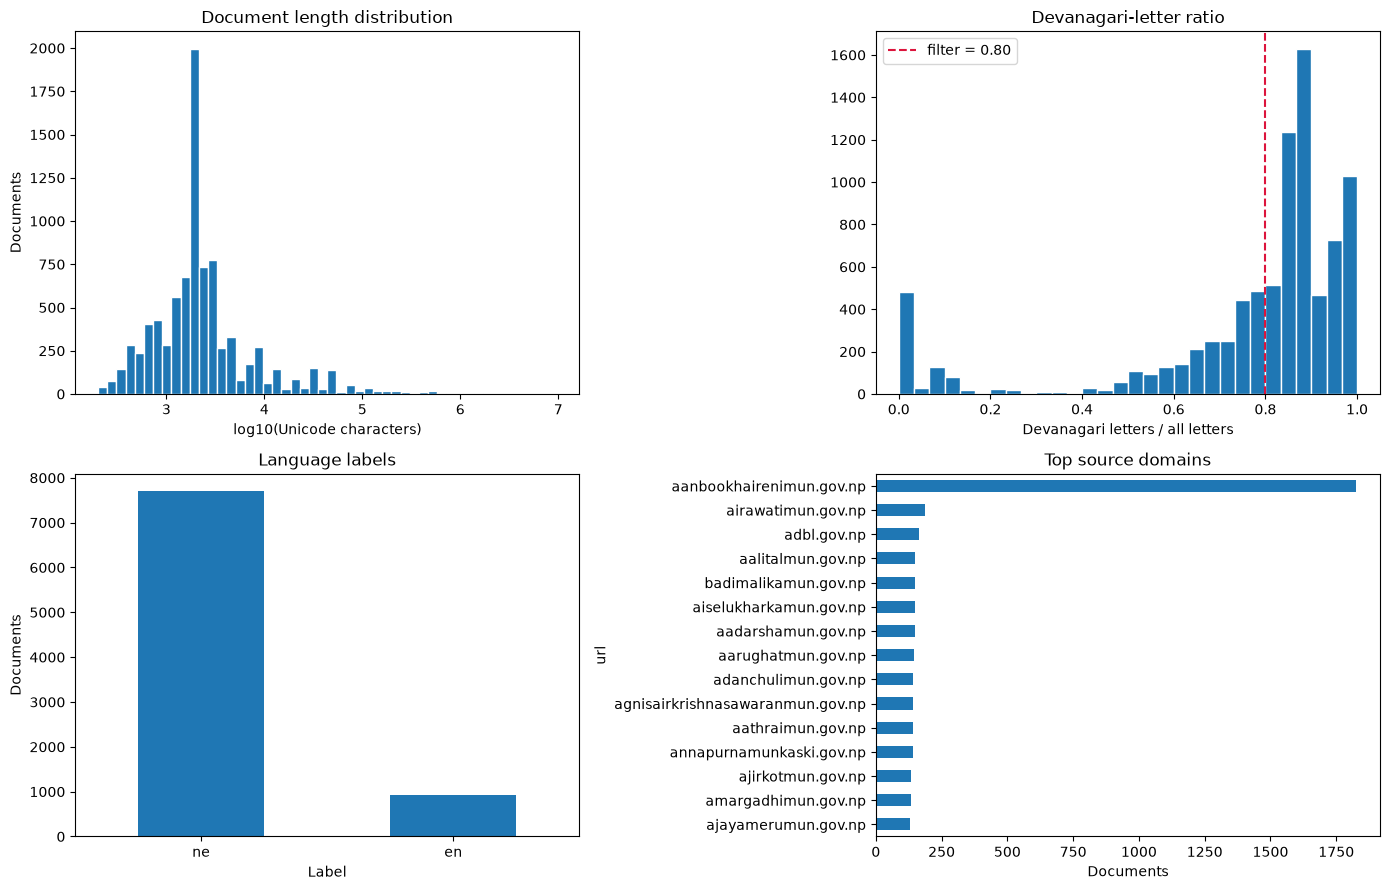

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

log_lengths = full_lengths.clip(lower=1).map(math.log10)
axes[0, 0].hist(log_lengths, bins=50, edgecolor="white")
axes[0, 0].set_title("Document length distribution")
axes[0, 0].set_xlabel("log10(Unicode characters)")
axes[0, 0].set_ylabel("Documents")

axes[0, 1].hist(full_ratios, bins=30, range=(0, 1), edgecolor="white")
axes[0, 1].axvline(0.80, color="crimson", linestyle="--", label="filter = 0.80")
axes[0, 1].set_title("Devanagari-letter ratio")
axes[0, 1].set_xlabel("Devanagari letters / all letters")
axes[0, 1].legend()

local_df["language"].fillna("<missing>").value_counts().plot.bar(ax=axes[1, 0])
axes[1, 0].set_title("Language labels")
axes[1, 0].set_xlabel("Label")
axes[1, 0].set_ylabel("Documents")
axes[1, 0].tick_params(axis="x", rotation=0)

full_domains.value_counts().head(15).sort_values().plot.barh(ax=axes[1, 1])
axes[1, 1].set_title("Top source domains")
axes[1, 1].set_xlabel("Documents")

fig.tight_layout()
plt.show()

In [12]:
eda_rows = local_df[["id", "language", "url"]].copy()
eda_rows["characters"] = full_lengths
eda_rows["devanagari_ratio"] = full_ratios
eda_rows["domain"] = full_domains
eda_rows["preview"] = texts.map(lambda text: compact_preview(text, 240))

print("Longest documents")
display(eda_rows.nlargest(10, "characters")[["id", "characters", "devanagari_ratio", "domain", "preview"]])

print("Lowest Devanagari-ratio documents")
display(eda_rows.nsmallest(10, "devanagari_ratio")[["id", "characters", "devanagari_ratio", "domain", "preview"]])

boilerplate_markers = (
    "skip to main content",
    "search form",
    "privacy policy",
    "all rights reserved",
    "cookie",
    "javascript",
)
boilerplate_counts = Counter()
for text in texts:
    lowered = text.casefold()
    boilerplate_counts.update(marker for marker in boilerplate_markers if marker in lowered)
display(pd.Series(boilerplate_counts, name="documents").sort_values(ascending=False).to_frame())

Longest documents


,id,characters,devanagari_ratio,domain,preview
5787,add126d3420fc406799481b10300eb14,9564648,0.995789,nepalpolice.gov.np,ताजा हरू सबै यो हप्ता यो महिना अघिल्लो महिना अ...
6707,c8137d24ec913711b9d08d4f482bc52c,1654870,0.968649,admincourt.gov.np,प्रशासन सुधार सुझाव समितिको प्रतिवेदन २०७० प्र...
7414,dd7d5a4ea8fe5a02bd4689617a4ec698,1600672,0.521241,bhojpur.akc.gov.np,"| | | | | | | | | , | | | | | | --- | --- | --..."
2768,52f1ad64f200013f8f48468e24c4ad8a,1434545,0.000000,old.aepc.gov.np,THIS E COPY OF BID DOCUMENT IS FOR INFORMATION...
7793,e888fb84cf92770ac5a2e84e8585bb56,1245511,0.969658,hr.parliament.gov.np,सर्वोच्च अदालतबाट भएका सङ्घीय संसद र सङ्घीय सं...
3893,74d5d914753d2421f0d2bd254858a21c,932059,0.871145,ciaa.gov.np,२०७२ साल मंससर कार्यकारी सारांश पृष्ठभूमि विभि...
5755,ace179b8368227c5d6a87dbef98ab883,835136,0.705122,hr.parliament.gov.np,;+3Lo ;+;b ;]jf :dfl/sf aif{ !@ cÍ !! dª\l;/ @...
2409,4723e4dba06efdd702da03f690c9573d,717883,0.935615,hr.parliament.gov.np,# ;+3Lo;+;b;b:o ljj/0f @)*@ ## n]vg tyf;Dkfbg ...
4596,8b2133e2ec233c02fbe92f27b6452421,717883,0.935615,na.parliament.gov.np,# ;+3Lo;+;b;b:o ljj/0f @)*@ ## n]vg tyf;Dkfbg ...
1614,305a20590f09b5298c98c6ae2ae7e093,636877,0.806716,hr.parliament.gov.np,"# ;+3Lo;+;b;]jf :dfl/sf,@)*! jif{ !#cÍ !@dª\l;..."


Lowest Devanagari-ratio documents


,id,characters,devanagari_ratio,domain,preview
13,0094148b95023a840e0036158dfbe021,206,0.0,nepalpolice.gov.np,"/ rtQ sen 6rqf€, ffiro. orGqrdl. mrw {iul ttRI..."
22,014ec96465431d764cb5801ddbf4fe49,5042,0.0,ausb.gov.np,Welcome to Auditing Standards Board Login Acco...
50,023e4dd32ec4e9b10c07f29e395634d7,2706,0.0,aepc.gov.np,| Pure platform 1 | Pure platform 2 | About Th...
81,0368f2258a73c7aad2267922d0154894,655,0.0,adodolpa.gov.np,"Ministry Of Land Management, Agriculture & Co-..."
99,04179d9ce902ab65f13d2a7dbae51b8f,1669,0.0,caanepal.gov.np,About CAAN Organization Structure CAAN Board M...
103,0442034a402dac954cac5e4e12ba4a16,795,0.0,ausb.gov.np,Welcome to Auditing Standards Board Login Acco...
108,0475509179badb4e7f7462a0ffdb1d55,5939,0.0,mofa.gov.np,A.D.: Nepal Samvat: 1146 CHAULATHWA NAWAMI - 9...
149,05771030ba88b345ef0bf421377ac1f4,217,0.0,agribiz.gov.np,Published Date : 2 18-11-2 (Modified Date : 2 ...
150,058f8ac5e3806ee97d998e4153917dc8,31141,0.0,ilam.akc.gov.np,"vFdr{{r, Efr vaqr{r \r4 vicr@i4 fd rrft i{rd q..."
154,05a8dad3e703e892411059d342d56bdc,31141,0.0,ilam.akc.gov.np,"vFdr{{r, Efr vaqr{r \r4 vicr@i4 fd rrft i{rd q..."


,documents
skip to main content,2553
search form,1179
all rights reserved,174
javascript,30
privacy policy,2


In [13]:
# Apply the repository cleaner as a dry simulation; no dataset files are changed.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from scripts.utils.nepali_text import CleaningConfig, clean_text_with_result

cleaning_config = CleaningConfig(
    mode="preserve",
    min_devanagari_ratio=0.80,
    min_devanagari_letters=10,
    min_characters=20,
)
rejection_reasons = Counter()
accepted_rows = 0
input_characters = 0
output_characters = 0

for text in texts:
    input_characters += len(text)
    result = clean_text_with_result(text, cleaning_config)
    if result.accepted:
        accepted_rows += 1
        output_characters += len(result.text)
    else:
        rejection_reasons[result.reason] += 1

print(f"Accepted rows       : {accepted_rows:,}/{len(texts):,} ({accepted_rows / len(texts):.1%})")
print(f"Character retention : {output_characters / max(1, input_characters):.1%}")
print("Rejection reasons   :", dict(rejection_reasons))
print("This simulation excludes exact-text deduplication and long-document chunking.")

Accepted rows       : 5,913/8,635 (68.5%)
Character retention : 71.3%
Rejection reasons   : {'low_ratio': 2722}
This simulation excludes exact-text deduplication and long-document chunking.


## Reading the full-corpus results

- Use the logarithmic length plot to understand both ordinary documents and extreme PDF outliers without capping them into one final bin.
- Treat language as supplied metadata, not proof that a row is Nepali; compare it with the measured script ratio.
- Review the longest and lowest-ratio rows manually before fixing thresholds.
- Boilerplate counts are lower bounds because they only search for a small marker list.
- The cleaning simulation is deliberately non-destructive. The final pipeline should deduplicate before splitting and chunk long documents only after document-level split assignment.